# Person 2: Supermarket Demand Forecasting
## Machine Learning Analysis — Random Forest

### Project Objective

The objective of this analysis is to develop a Machine Learning model for daily supermarket sales forecasting using historical sales data.

This notebook focuses on feature engineering, Random Forest regression, baseline forecasting, chronological evaluation, and business interpretation.

### Main Steps

1. Load and prepare the daily sales time series.
2. Perform exploratory data analysis.
3. Create lag-based, rolling-window, and calendar features.
4. Train a Random Forest regression model.
5. Evaluate predictions using a chronological holdout and rolling one-step forecasting.
6. Compare Random Forest with Naive and Seasonal Naive baselines.
7. Analyze residuals and generate a seven-day sales forecast.
8. Export model predictions and evaluation results for integration with Person 1's ARIMA analysis.

## 1. Setup and Imports

This section imports the libraries required for data manipulation, visualization, Machine Learning, and model evaluation.

- **NumPy:** Numerical operations.
- **Pandas:** Data manipulation and time series processing.
- **Matplotlib and Seaborn:** Data visualization.
- **RandomForestRegressor:** Machine Learning regression model.
- **Scikit-learn metrics:** Evaluation using MAE and RMSE.

In [1]:


from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries imported successfully.")


# Project paths
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "demand-forecasting-kernels-only"
TRAIN_PATH = DATA_DIR / "train.csv"
OUTPUT_DIR = PROJECT_DIR / "output"

# Check that the dataset exists
if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f"train.csv not found at: {TRAIN_PATH}\n"
        "Make sure the notebook is saved in the main project folder."
    )

# Load the original training data
raw = pd.read_csv(TRAIN_PATH)

print("Dataset loaded successfully!")
print("Shape:", raw.shape)
print("Columns:", raw.columns.tolist())
print("\nFirst 5 rows:")
display(raw.head())

# Prepare the date column
raw["date"] = pd.to_datetime(raw["date"])
raw = raw.sort_values("date").reset_index(drop=True)

# Aggregate sales across all stores and items per day
daily_sales = (
    raw.groupby("date")["sales"]
    .sum()
    .sort_index()
)

# Create a continuous daily date index
full_index = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

sales = daily_sales.reindex(full_index).fillna(0).astype(float)
sales.index.name = "date"
sales.name = "sales"

print("\nDaily sales series:")
print("Start date:", sales.index.min())
print("End date:", sales.index.max())
print("Number of days:", len(sales))
print("Missing values:", sales.isna().sum())
print("\nSummary statistics:")
display(sales.describe().to_frame())


Libraries imported successfully.
Dataset loaded successfully!
Shape: (913000, 4)
Columns: ['date', 'store', 'item', 'sales']

First 5 rows:


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10



Daily sales series:
Start date: 2013-01-01 00:00:00
End date: 2017-12-31 00:00:00
Number of days: 1826
Missing values: 0

Summary statistics:


,sales
count,1826.000000
mean,26125.143483
std,6418.270181
min,11709.000000
25%,21195.000000
50%,25839.500000
75%,30779.500000
max,44936.000000


## 2. Data Preparation

The dataset contains daily sales records for multiple stores and items.

To maintain consistency with Person 1's analysis, sales are aggregated across all stores and items into a single daily time series.

The preparation steps include:

- Loading the training dataset.
- Converting the date column to datetime.
- Sorting observations chronologically.
- Aggregating total sales by date.
- Creating a continuous daily date index.
- Checking the date range, missing values, and summary statistics.

In [2]:

if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f"train.csv not found at: {TRAIN_PATH}"
    )

raw = pd.read_csv(TRAIN_PATH)

print("Dataset shape:", raw.shape)
print("Columns:", raw.columns.tolist())
print("\nMissing values in raw data:")
display(raw.isna().sum().to_frame("Missing Values"))

raw["date"] = pd.to_datetime(raw["date"])
raw = raw.sort_values("date").reset_index(drop=True)

daily_sales = raw.groupby("date")["sales"].sum().sort_index()

full_index = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

sales = daily_sales.reindex(full_index).fillna(0).astype(float)
sales.index.name = "date"
sales.name = "sales"

print("\nDaily sales series")
print("Start:", sales.index.min())
print("End:", sales.index.max())
print("Number of days:", len(sales))
print("Missing values:", sales.isna().sum())

display(sales.describe().to_frame())


Dataset shape: (913000, 4)
Columns: ['date', 'store', 'item', 'sales']

Missing values in raw data:


,Missing Values
date,0
store,0
item,0
sales,0



Daily sales series
Start: 2013-01-01 00:00:00
End: 2017-12-31 00:00:00
Number of days: 1826
Missing values: 0


,sales
count,1826.000000
mean,26125.143483
std,6418.270181
min,11709.000000
25%,21195.000000
50%,25839.500000
75%,30779.500000
max,44936.000000


## 3. Exploratory Data Analysis

This section examines the overall distribution and behavior of daily supermarket sales.

The analysis includes:

- A time series plot of daily total sales.
- A histogram showing the sales distribution.
- Average sales by day of the week.

These visualizations help identify general trends, variability, and potential weekly demand patterns before building the Machine Learning model.

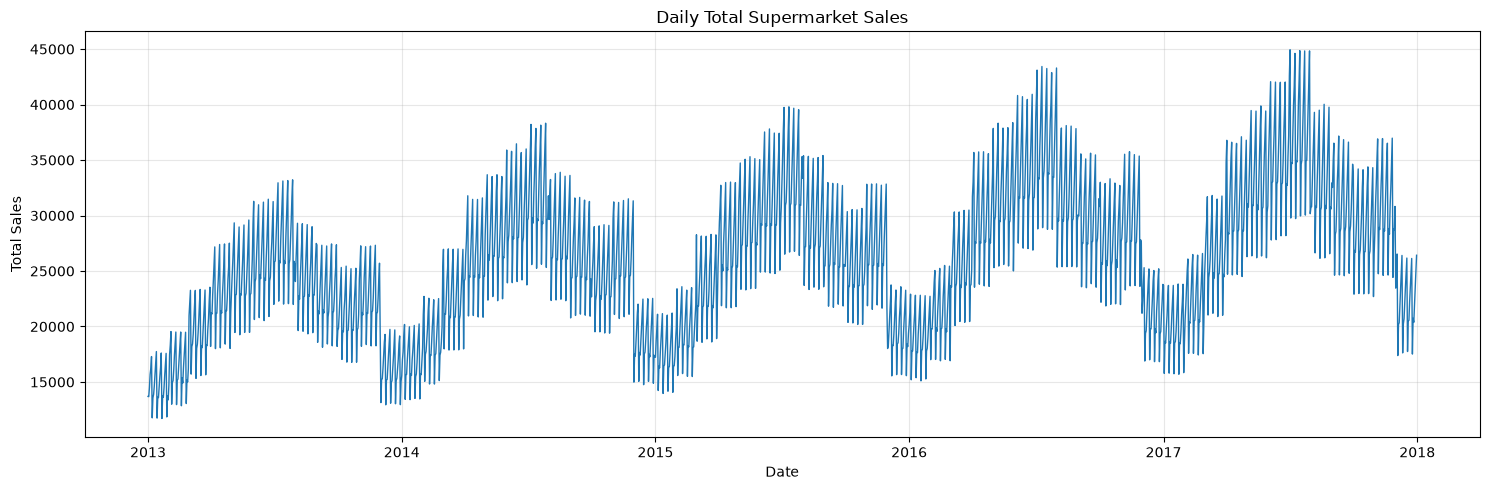

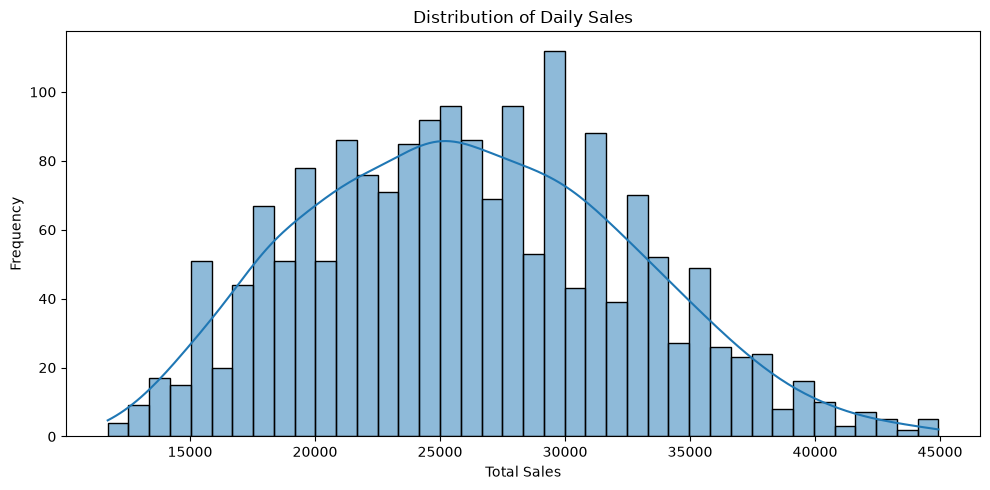

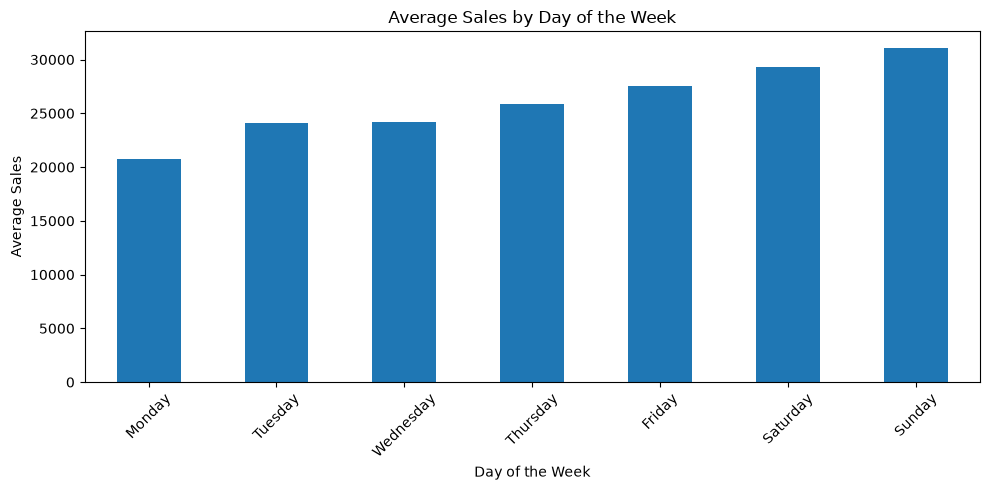

,Average Sales
Monday,20714.819231
Tuesday,24112.954023
Wednesday,24184.252874
Thursday,25861.609195
Friday,27578.624521
Saturday,29331.348659
Sunday,31071.666667


In [2]:

# Daily sales over time
plt.figure(figsize=(15, 5))
plt.plot(sales.index, sales.values, linewidth=1)
plt.title("Daily Total Supermarket Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Sales distribution
plt.figure(figsize=(10, 5))
sns.histplot(sales, bins=40, kde=True)
plt.title("Distribution of Daily Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Average sales by weekday
weekday_names = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_avg = sales.groupby(sales.index.dayofweek).mean()
weekday_avg.index = weekday_names

plt.figure(figsize=(10, 5))
weekday_avg.plot(kind="bar")
plt.title("Average Sales by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(weekday_avg.rename("Average Sales").to_frame())


## 4. Chronological Train / Test Split

The daily sales series is divided chronologically into training and holdout sets.

The first 1,736 days are used for training, while the final 90 days are reserved for evaluation. This follows the same split used by Person 1 and avoids randomly mixing past and future observations.

The holdout period is evaluated using rolling one-step forecasts, where actual observations become available sequentially after each prediction.

In [3]:

# Reserve the final 90 days for evaluation
HOLDOUT_DAYS = 90

train = sales.iloc[:-HOLDOUT_DAYS].copy()
holdout = sales.iloc[-HOLDOUT_DAYS:].copy()

print("Training period:", train.index.min().date(), "to", train.index.max().date())
print("Holdout period:", holdout.index.min().date(), "to", holdout.index.max().date())

print("Training observations:", len(train))
print("Holdout observations:", len(holdout))

assert len(train) == 1736
assert len(holdout) == 90
assert train.index[-1] < holdout.index[0]

print("\nChronological split completed successfully.")


Training period: 2013-01-01 to 2017-10-02
Holdout period: 2017-10-03 to 2017-12-31
Training observations: 1736
Holdout observations: 90

Chronological split completed successfully.


## 5. Feature Engineering

Random Forest requires a tabular feature matrix rather than relying on the time series index alone.

Historical sales are transformed into predictive features, including:

- **Lag features:** Sales from previous days and weeks.
- **Rolling averages:** Mean sales over previous 7, 14, and 28 days.
- **Calendar features:** Day of the week, day of the month, and month.
- **Weekend indicator:** Identifies Saturday and Sunday.

All rolling averages are calculated using past observations only to avoid target leakage.

In [5]:

def make_features(series):
    features = pd.DataFrame(index=series.index)

    # Historical sales
    features["lag_1"] = series.shift(1)
    features["lag_7"] = series.shift(7)
    features["lag_14"] = series.shift(14)
    features["lag_28"] = series.shift(28)

    # Rolling averages based only on previous observations
    shifted_sales = series.shift(1)
    features["rolling_mean_7"] = shifted_sales.rolling(7).mean()
    features["rolling_mean_14"] = shifted_sales.rolling(14).mean()
    features["rolling_mean_28"] = shifted_sales.rolling(28).mean()

    # Calendar features
    features["day_of_week"] = series.index.dayofweek
    features["day_of_month"] = series.index.day
    features["month"] = series.index.month
    features["is_weekend"] = (
        series.index.dayofweek >= 5
    ).astype(int)

    return features


# Create features using historical sales
all_features = make_features(sales)

# Train features: use only dates belonging to the training period
X_train = all_features.loc[train.index].dropna().copy()
y_train = train.loc[X_train.index].copy()

# Holdout features: each date uses observations available before that date
X_test = all_features.loc[holdout.index].copy()
y_test = holdout.copy()

print("Training feature shape:", X_train.shape)
print("Training target shape:", y_train.shape)
print("Holdout feature shape:", X_test.shape)
print("Holdout target shape:", y_test.shape)

print("\nFeature columns:")
print(X_train.columns.tolist())

display(X_train.head())


Training feature shape: (1708, 11)
Training target shape: (1708,)
Holdout feature shape: (90, 11)
Holdout target shape: (90,)

Feature columns:
['lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'day_of_week', 'day_of_month', 'month', 'is_weekend']


,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,day_of_week,day_of_month,month,is_weekend
date,,,,,,,,,,,
2013-01-29,11848.0,13724.0,13625.0,13696.0,14776.714286,14739.285714,14752.321429,1,29,1,0
2013-01-30,13724.0,13613.0,13591.0,13678.0,14776.714286,14746.357143,14753.321429,2,30,1,0
2013-01-31,13391.0,14472.0,14587.0,14488.0,14745.000000,14732.071429,14743.071429,3,31,1,0
2013-02-01,14724.0,15640.0,15495.0,15677.0,14781.000000,14741.857143,14751.500000,4,1,2,0
2013-02-02,17473.0,16561.0,16294.0,16237.0,15042.857143,14883.142857,14815.642857,5,2,2,1


## 6. Baseline Forecasting Models

Before evaluating Random Forest, two simple forecasting baselines are established.

1. **Naive Forecast:** Predicts each day's sales using the previous day's actual sales.
2. **Seasonal Naive Forecast:** Predicts each day's sales using the actual sales from seven days earlier.

These baselines provide reference points to determine whether the Machine Learning model improves forecasting accuracy.

In [6]:

# Naive: use sales from the previous day
naive_predictions = sales.shift(1).loc[holdout.index].astype(float)

# Seasonal Naive: use sales from seven days earlier
seasonal_naive_predictions = sales.shift(7).loc[holdout.index].astype(float)

baseline_predictions = {
    "Naive": naive_predictions,
    "Seasonal Naive": seasonal_naive_predictions,
}

print("Baseline predictions prepared.")
display(pd.DataFrame({
    "Actual": holdout,
    "Naive": naive_predictions,
    "Seasonal Naive": seasonal_naive_predictions,
}).head(10))


Baseline predictions prepared.


,Actual,Naive,Seasonal Naive
date,,,
2017-10-03,26854.0,22913.0,28537.0
2017-10-04,26691.0,26854.0,29056.0
2017-10-05,28357.0,26691.0,30535.0
2017-10-06,30225.0,28357.0,32700.0
2017-10-07,32189.0,30225.0,34623.0
2017-10-08,34194.0,32189.0,33845.0
2017-10-09,22974.0,34194.0,22913.0
2017-10-10,26478.0,22974.0,26854.0
2017-10-11,26899.0,26478.0,26691.0


## 7. Random Forest Model Training

A Random Forest Regressor is trained to predict daily supermarket sales using the engineered lag-based, rolling-window, and calendar features.

The model combines multiple decision trees to capture nonlinear relationships between historical sales patterns and future demand.

The model is trained exclusively on the training period. Its performance is then evaluated on the 90-day holdout period using rolling one-step predictions, where actual sales from previous days are available when predicting the next day.

In [7]:
# Initialize the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model using training data only
rf_model.fit(X_train, y_train)

# Generate rolling one-step predictions for the holdout period
rf_predictions = pd.Series(
    rf_model.predict(X_test),
    index=holdout.index,
    name="Random Forest"
)

print("Random Forest model trained successfully.")
print("Number of trees:", rf_model.n_estimators)
print("Training observations:", len(X_train))
print("Holdout predictions:", len(rf_predictions))

display(
    pd.DataFrame({
        "Actual": y_test,
        "Random Forest": rf_predictions
    }).head(10)
)

Random Forest model trained successfully.
Number of trees: 300
Training observations: 1708
Holdout predictions: 90


,Actual,Random Forest
date,,
2017-10-03,26854.0,27244.756360
2017-10-04,26691.0,28240.305013
2017-10-05,28357.0,28261.022903
2017-10-06,30225.0,30359.736138
2017-10-07,32189.0,32099.493757
2017-10-08,34194.0,33640.737472
2017-10-09,22974.0,22736.783354
2017-10-10,26478.0,27191.184645
2017-10-11,26899.0,26942.082560


## 8. Model Evaluation and Baseline Comparison

The Random Forest model is evaluated using three regression metrics:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted sales.
- **Root Mean Squared Error (RMSE):** Penalizes larger prediction errors more heavily.
- **Mean Absolute Percentage Error (MAPE):** Expresses the average absolute prediction error as a percentage of actual sales.

The Random Forest results are compared with the Naive and Seasonal Naive baselines using the same holdout observations. Lower metric values indicate better forecasting accuracy.

In [8]:
def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }


predictions = {
    "Naive": naive_predictions,
    "Seasonal Naive": seasonal_naive_predictions,
    "Random Forest": rf_predictions
}

comparison_results = []

for model_name, model_predictions in predictions.items():
    metrics = calculate_metrics(y_test, model_predictions)

    comparison_results.append({
        "Model": model_name,
        **metrics
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values("RMSE").reset_index(drop=True)

print("Holdout Performance Comparison:")
display(comparison_df.round(2))

best_model = comparison_df.loc[0, "Model"]
print("Best model by RMSE:", best_model)

Holdout Performance Comparison:


,Model,MAE,RMSE,MAPE (%)
0,Random Forest,671.54,1387.48,2.71
1,Seasonal Naive,1154.64,2674.65,4.75
2,Naive,3108.08,4500.75,12.66


Best model by RMSE: Random Forest


## 9. Feature Importance Analysis

Random Forest provides feature importance scores that estimate how much each feature contributes to the model's predictions.

This analysis helps identify which historical sales patterns and calendar variables are most influential in forecasting daily supermarket demand.

Feature importance indicates predictive contribution within this trained model; it does not establish a causal relationship.

,Feature,Importance
0,lag_7,0.9094
1,lag_1,0.0587
2,month,0.0148
3,day_of_month,0.0094
4,rolling_mean_7,0.0024
5,day_of_week,0.0015
6,lag_28,0.0013
7,lag_14,0.0010
8,rolling_mean_28,0.0008
9,rolling_mean_14,0.0007


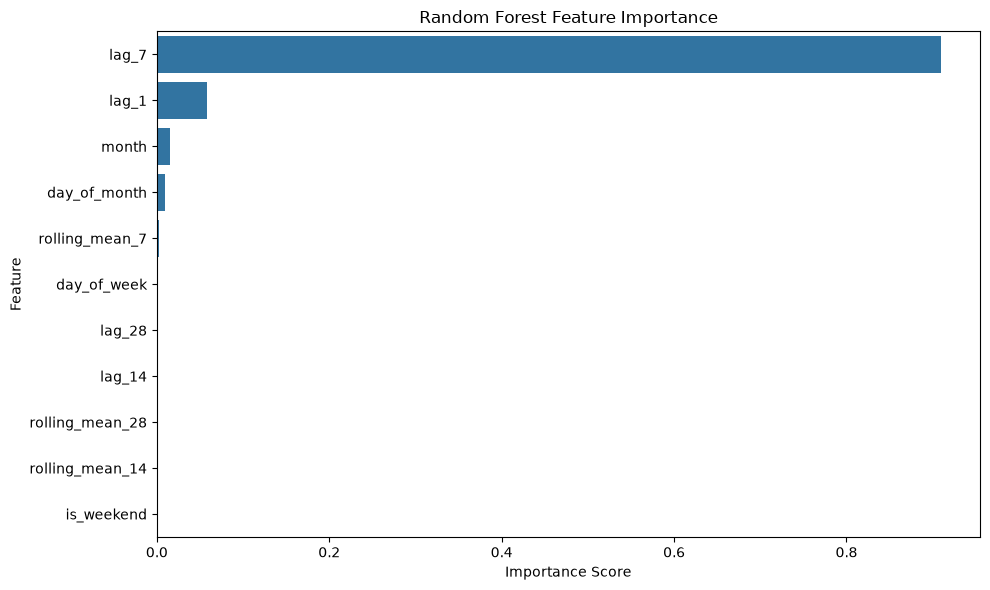

In [9]:
# Extract feature importance scores
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance.round(4))

# Visualize the most important features
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. Residual Analysis

Residuals are calculated as actual sales minus predicted sales.

Analyzing residuals helps assess the magnitude and distribution of forecasting errors and identify periods when the model overestimates or underestimates demand.

A residual close to zero indicates an accurate prediction, while a positive residual indicates underprediction and a negative residual indicates overprediction.

Residual summary:


count      90.00
mean       -8.15
std      1395.23
min     -8093.53
25%      -162.03
50%       113.97
75%       414.37
max      3010.82
Name: Residual, dtype: float64

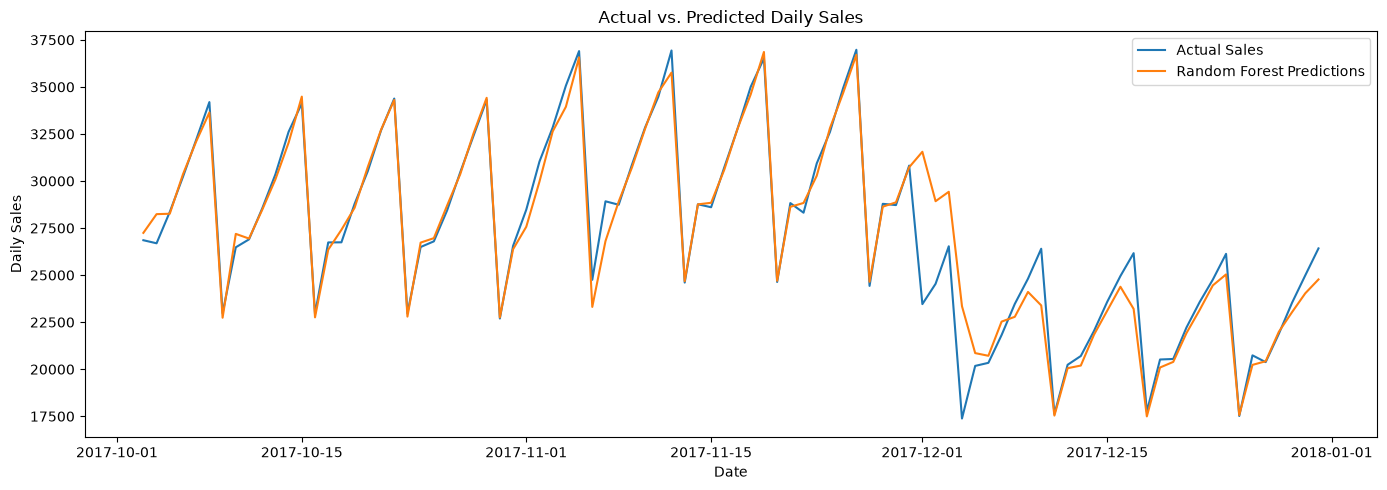

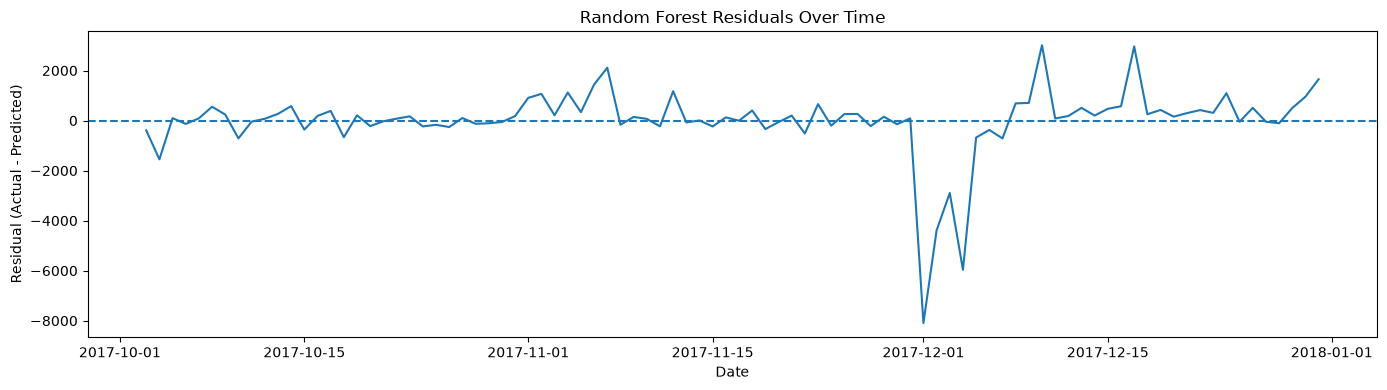

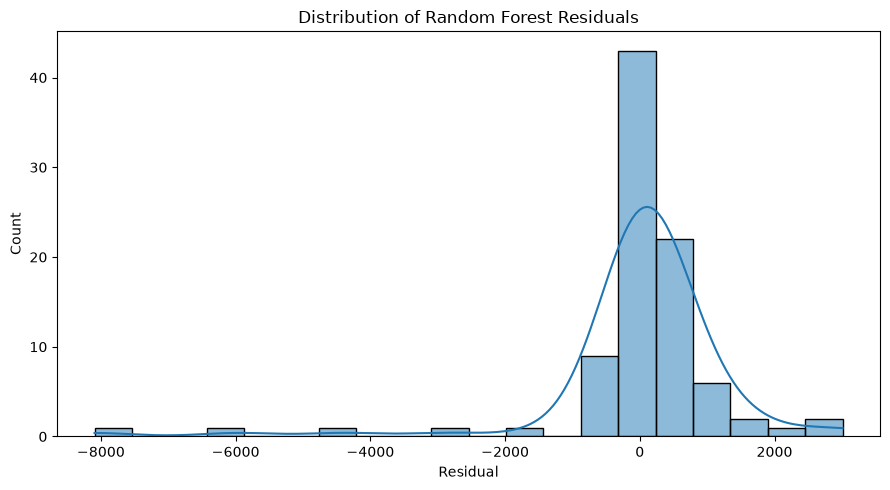

In [10]:
# Calculate holdout residuals
rf_residuals = (y_test - rf_predictions).rename("Residual")

print("Residual summary:")
display(rf_residuals.describe().round(2))

# Plot actual versus predicted sales
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label="Actual Sales")
plt.plot(rf_predictions.index, rf_predictions, label="Random Forest Predictions")
plt.title("Actual vs. Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.tight_layout()
plt.show()

# Plot residuals over time
plt.figure(figsize=(14, 4))
plt.axhline(0, linestyle="--")
plt.plot(rf_residuals.index, rf_residuals)
plt.title("Random Forest Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Plot residual distribution
plt.figure(figsize=(9, 5))
sns.histplot(rf_residuals, bins=20, kde=True)
plt.title("Distribution of Random Forest Residuals")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

## 11. Seven-Day Recursive Sales Forecast

After evaluating the model on the holdout period, a final Random Forest model is trained using all available historical observations.

A recursive forecasting strategy is then used to predict sales for the next seven days. Each predicted value is added to the available history and used to construct features for the following day.

Because actual future sales are unavailable, the seven-day forecast relies on previous observations and earlier predictions.

C:\Users\samae\AppData\Local\Temp\ipykernel_211408\3425293391.py:33: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  start=sales.index[-1] + pd.Timedelta(days=1),


Seven-day forecast:


,Predicted_Sales
Date,
2018-01-01,18400.91
2018-01-02,21191.14
2018-01-03,21899.81
2018-01-04,23991.27
2018-01-05,26026.02
2018-01-06,28385.28
2018-01-07,29832.01


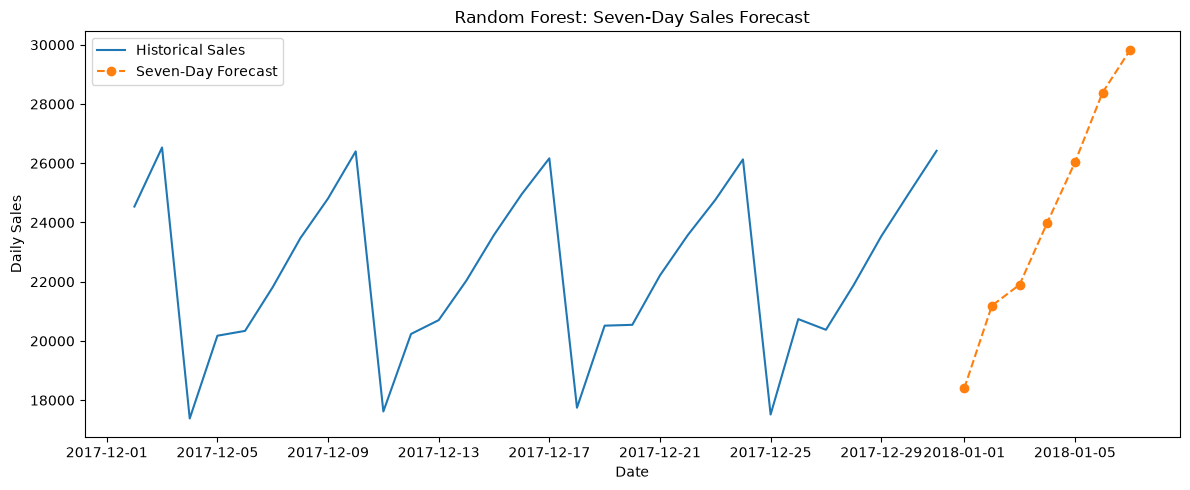

In [11]:
# Train a final model using all available labeled observations
final_training_features = all_features.dropna()
final_training_target = sales.loc[final_training_features.index]

final_rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(final_training_features, final_training_target)

# Build features for one future date using history available at that point
def make_next_features(history, next_date):
    return pd.DataFrame([{
        "lag_1": history.iloc[-1],
        "lag_7": history.iloc[-7],
        "lag_14": history.iloc[-14],
        "lag_28": history.iloc[-28],
        "rolling_mean_7": history.iloc[-7:].mean(),
        "rolling_mean_14": history.iloc[-14:].mean(),
        "rolling_mean_28": history.iloc[-28:].mean(),
        "day_of_week": next_date.dayofweek,
        "day_of_month": next_date.day,
        "month": next_date.month,
        "is_weekend": int(next_date.dayofweek >= 5)
    }], index=[next_date])

# Generate recursive predictions for the next seven days
history = sales.copy()
future_dates = pd.date_range(
    start=sales.index[-1] + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

future_predictions = []

for future_date in future_dates:
    next_row = make_next_features(history, future_date)
    prediction = final_rf_model.predict(next_row)[0]

    future_predictions.append(prediction)

    # Add the prediction to history for subsequent forecast steps
    history.loc[future_date] = prediction

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Sales": future_predictions
}).set_index("Date")

print("Seven-day forecast:")
display(forecast_df.round(2))

# Plot the forecast
plt.figure(figsize=(12, 5))
plt.plot(sales.index[-30:], sales.iloc[-30:], label="Historical Sales")
plt.plot(
    forecast_df.index,
    forecast_df["Predicted_Sales"],
    marker="o",
    linestyle="--",
    label="Seven-Day Forecast"
)
plt.title("Random Forest: Seven-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Export Results for Project Integration

The model comparison, holdout predictions, residuals, and seven-day forecast are exported as CSV files.

These outputs support reproducibility and allow the Random Forest results to be integrated with the ARIMA and SARIMAX analysis developed by Person 1.

In [12]:
# Create output directory
output_dir = Path("output")
output_dir.mkdir(parents=True, exist_ok=True)

# Save model comparison
comparison_df.to_csv(
    output_dir / "person2_model_comparison.csv",
    index=False
)

# Save holdout predictions and actual values
validation_df = pd.DataFrame({
    "Actual": y_test,
    "Naive": naive_predictions,
    "Seasonal_Naive": seasonal_naive_predictions,
    "Random_Forest": rf_predictions
})
validation_df.to_csv(
    output_dir / "person2_validation_predictions.csv",
    index_label="date"
)

# Save Random Forest residuals
rf_residuals.to_frame().to_csv(
    output_dir / "person2_residuals.csv",
    index_label="date"
)

# Save seven-day forecast
forecast_df.to_csv(
    output_dir / "person2_7_day_forecast.csv",
    index_label="date"
)

print("Files exported successfully:")
for file_path in sorted(output_dir.glob("person2_*.csv")):
    print(file_path)

Files exported successfully:
output\person2_7_day_forecast.csv
output\person2_model_comparison.csv
output\person2_residuals.csv
output\person2_validation_predictions.csv


## 13. Integrated Model Comparison

This section combines the evaluation results from Person 1's ARIMA analysis with Person 2's Machine Learning models.

The comparison uses the exported model evaluation metrics to identify the strongest forecasting results. Model comparisons should be interpreted only when the evaluation period and forecasting protocol are consistent.

In [13]:
# Load Person 1 and Person 2 evaluation results
output_dir = Path("output")

person1_comparison = pd.read_csv(
    output_dir / "arima_model_comparison.csv"
)

person2_comparison = pd.read_csv(
    output_dir / "person2_model_comparison.csv"
)

print("Person 1 comparison columns:")
print(person1_comparison.columns.tolist())

print("\nPerson 1 model comparison:")
display(person1_comparison)

print("\nPerson 2 model comparison:")
display(person2_comparison)

Person 1 comparison columns:
['Family', 'Model', 'Order', 'Seasonal_Order', 'Protocol', 'AIC', 'BIC', 'MAE', 'RMSE', 'MAPE', 'Convergence']

Person 1 model comparison:


,Family,Model,Order,Seasonal_Order,Protocol,AIC,BIC,MAE,RMSE,MAPE,Convergence
0,SARIMAX,"SARIMAX(1, 1, 1)x(1, 1, 1, 7)","(1, 1, 1)","(1, 1, 1, 7)",rolling_one_step_refit_false,27734.07777127864,27761.325261305556,619.376806,1222.848946,2.572304,OK
1,SARIMAX,"SARIMAX(2, 1, 1)x(1, 1, 1, 7)","(2, 1, 1)","(1, 1, 1, 7)",rolling_one_step_refit_false,27726.789899329273,27759.48688736157,608.221655,1223.848112,2.528684,OK
2,SARIMAX,"SARIMAX(0, 1, 1)x(0, 1, 1, 7)","(0, 1, 1)","(0, 1, 1, 7)",rolling_one_step_refit_false,27766.538775396395,27782.887269412542,574.741127,1237.425792,2.416837,OK
3,SARIMAX,"SARIMAX(1, 1, 0)x(1, 1, 0, 7)","(1, 1, 0)","(1, 1, 0, 7)",rolling_one_step_refit_false,27975.144371011516,27991.49460972094,596.610942,1334.311611,2.457186,OK
4,Baseline,Seasonal-Naive (7 days ago),-,-,rolling_one_step_reference,baseline_reference,baseline_reference,1154.644444,2674.646116,4.748865,reference
5,ARIMA,"ARIMA(2, 0, 1)","(2, 0, 1)",-,rolling_one_step_refit_false,33420.77027937694,33448.06121016364,2959.864569,3865.417352,11.708834,OK
6,ARIMA,"ARIMA(1, 1, 1)","(1, 1, 1)",-,rolling_one_step_refit_false,33412.25392720728,33428.62675507643,2954.547760,3881.547687,11.736622,OK
7,ARIMA,"ARIMA(2, 1, 1)","(2, 1, 1)",-,rolling_one_step_refit_false,33476.19090470484,33498.0213418637,2984.876792,3953.214179,12.003690,OK
8,ARIMA,"ARIMA(1, 0, 1)","(1, 0, 1)",-,rolling_one_step_refit_false,33475.4983702386,33497.331114867964,3284.062245,4002.263695,12.822103,OK
9,ARIMA,"ARIMA(0, 1, 1)","(0, 1, 1)",-,rolling_one_step_refit_false,33468.82721932797,33479.7424379074,3294.009661,4019.591082,12.893887,OK



Person 2 model comparison:


,Model,MAE,RMSE,MAPE (%)
0,Random Forest,671.540813,1387.478436,2.709320
1,Seasonal Naive,1154.644444,2674.646116,4.748865
2,Naive,3108.077778,4500.752415,12.663518


## 14. Final Comparison and Conclusion

The evaluation results show that the SARIMAX model achieved the lowest RMSE among the reported forecasting models, with an RMSE of 1,222.85 and a MAPE of 2.57%.

The Random Forest model achieved an RMSE of 1,387.48 and a MAPE of 2.71%, outperforming both the Naive and Seasonal Naive baselines.

The Random Forest results demonstrate that lag-based features and calendar information can effectively capture daily supermarket sales patterns. Feature importance analysis identified `lag_7` as the most influential feature.

Overall, SARIMAX achieved the strongest reported holdout accuracy, while Random Forest provided a competitive machine learning alternative. Final model selection should also consider forecasting requirements, computational cost, and consistency of the evaluation protocol.

In [14]:
# Select comparable evaluation metrics from both notebooks
person1_summary = person1_comparison[
    ["Family", "Model", "Protocol", "MAE", "RMSE", "MAPE"]
].copy()

person1_summary["MAPE"] = person1_summary["MAPE"].astype(float)
person1_summary["Source"] = "Person 1"

person2_summary = person2_comparison[
    ["Model", "MAE", "RMSE", "MAPE (%)"]
].copy()

person2_summary = person2_summary.rename(
    columns={"MAPE (%)": "MAPE"}
)

person2_summary["Family"] = person2_summary["Model"].map({
    "Random Forest": "Machine Learning",
    "Seasonal Naive": "Baseline",
    "Naive": "Baseline"
})

person2_summary["Protocol"] = "rolling_one_step"
person2_summary["Source"] = "Person 2"

# Combine results
final_comparison = pd.concat(
    [person1_summary, person2_summary],
    ignore_index=True
)

final_comparison = final_comparison.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)

display(final_comparison.round(3))

# Export integrated comparison
final_comparison.to_csv(
    output_dir / "final_model_comparison.csv",
    index=False
)

print("Final comparison exported to output/final_model_comparison.csv")

,Family,Model,Protocol,MAE,RMSE,MAPE,Source
0,SARIMAX,"SARIMAX(1, 1, 1)x(1, 1, 1, 7)",rolling_one_step_refit_false,619.377,1222.849,2.572,Person 1
1,SARIMAX,"SARIMAX(2, 1, 1)x(1, 1, 1, 7)",rolling_one_step_refit_false,608.222,1223.848,2.529,Person 1
2,SARIMAX,"SARIMAX(0, 1, 1)x(0, 1, 1, 7)",rolling_one_step_refit_false,574.741,1237.426,2.417,Person 1
3,SARIMAX,"SARIMAX(1, 1, 0)x(1, 1, 0, 7)",rolling_one_step_refit_false,596.611,1334.312,2.457,Person 1
4,Machine Learning,Random Forest,rolling_one_step,671.541,1387.478,2.709,Person 2
5,Baseline,Seasonal-Naive (7 days ago),rolling_one_step_reference,1154.644,2674.646,4.749,Person 1
6,Baseline,Seasonal Naive,rolling_one_step,1154.644,2674.646,4.749,Person 2
7,ARIMA,"ARIMA(2, 0, 1)",rolling_one_step_refit_false,2959.865,3865.417,11.709,Person 1
8,ARIMA,"ARIMA(1, 1, 1)",rolling_one_step_refit_false,2954.548,3881.548,11.737,Person 1
9,ARIMA,"ARIMA(2, 1, 1)",rolling_one_step_refit_false,2984.877,3953.214,12.004,Person 1


Final comparison exported to output/final_model_comparison.csv
